# VLM Document Validation — Interactive Eval

Sections:
1. Setup
2. Ground truth
3. Single image test
4. Bulk run
5. Metrics
6. Model comparison

## 1. Setup

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd() / "src"))

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, f1_score

from document_validation.ground_truth import load_ground_truth, make_subset
from document_validation.vlm_detector import VlmDetector, MODEL_REGISTRY
from document_validation.validator import ValidationConfig, _render_pdf_pages, _load_image

# ── Choose model and dataset ──────────────────────────────────────────────────
MODEL_KEY = "smolvlm"   # change to any key in MODEL_REGISTRY
USE_FULL  = False       # True = full dataset, False = 72-file subset

CONFIG       = ValidationConfig(pdf_dpi=200)
PROJECT_ROOT = Path.cwd()
TEST_DATA    = PROJECT_ROOT / "test_data"
OUT_DIR      = PROJECT_ROOT / "eval_results"
OUT_DIR.mkdir(exist_ok=True)

LABELS = ["accepted", "blur", "cut", "not_document"]
print("Available models:", list(MODEL_REGISTRY))
print("Selected model  :", MODEL_KEY)

Available models: ['qwen2-vl-2b', 'internvl2-2b', 'moondream2', 'smolvlm', 'phi35-vision', 'llava-phi3']
Selected model  : smolvlm


## 2. Ground Truth

In [7]:
gt_df = load_ground_truth(TEST_DATA)
print(f"Total labeled files: {len(gt_df)}")
gt_df.groupby(["doc_type", "expected_label"]).size().unstack(fill_value=0)

Total labeled files: 660


expected_label,accepted,blur,cut,not_document
doc_type,,,,
ConcentForm,107,70,36,36
Landrecord,180,115,60,56


In [8]:
SUBSET_CSV = OUT_DIR / "vlm_subset.csv"
if SUBSET_CSV.exists():
    subset_df = pd.read_csv(SUBSET_CSV)
    subset_df["file_path"] = subset_df["file_path"].apply(Path)
    print(f"Loaded existing subset: {len(subset_df)} files")
else:
    subset_df = make_subset(gt_df, n_per_class=18, seed=42)
    subset_df.to_csv(SUBSET_CSV, index=False)
    print(f"Created subset: {len(subset_df)} files → {SUBSET_CSV}")

eval_df = gt_df if USE_FULL else subset_df
print(f"\nEval dataset: {len(eval_df)} files")
eval_df["expected_label"].value_counts()

Loaded existing subset: 72 files

Eval dataset: 72 files


expected_label
accepted        18
blur            18
cut             18
not_document    18
Name: count, dtype: int64

## 3. Single Image Test

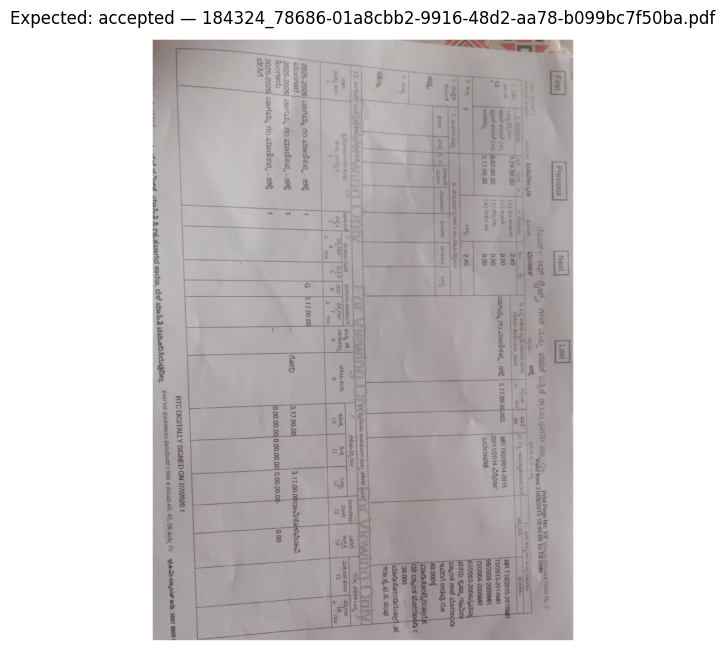

Predicted : None
Expected  : accepted
Latency   : 0.01s


In [11]:
import time

# pick any file to test — change index to explore
sample = eval_df.iloc[3]
fp = Path(sample["file_path"])

if fp.suffix.lower() == ".pdf":
    page_bgr = list(_render_pdf_pages(fp, CONFIG))[0]
else:
    page_bgr = _load_image(fp)

rgb = cv2.cvtColor(page_bgr, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(6, 8))
plt.imshow(rgb)
plt.title(f"Expected: {sample['expected_label']} — {fp.name}")
plt.axis("off")
plt.show()

detector = VlmDetector(MODEL_KEY)
t0 = time.time()
vote = detector.detect(page_bgr, fp, 1, CONFIG)
print(f"Predicted : {vote.label}")
print(f"Expected  : {sample['expected_label']}")
print(f"Latency   : {time.time()-t0:.2f}s")

## 4. Bulk Run

In [12]:
import time

RESULTS_CSV = OUT_DIR / f"vlm_{MODEL_KEY}_results.csv"

rows = []
n = len(eval_df)
for i, (_, row) in enumerate(eval_df.iterrows()):
    fp = Path(row["file_path"])
    t0 = time.time()
    try:
        if fp.suffix.lower() == ".pdf":
            page = list(_render_pdf_pages(fp, CONFIG))[0]
        else:
            page = _load_image(fp)
        vote = detector.detect(page, fp, 1, CONFIG)
        predicted = vote.label or "accepted"
    except Exception as exc:
        predicted = "error"
    rows.append({**row.to_dict(), "predicted_label": predicted, "latency_s": round(time.time()-t0, 2)})
    if (i+1) % 10 == 0 or i == n-1:
        print(f"  {i+1}/{n}", end="\r")

results_df = pd.DataFrame(rows)
results_df.to_csv(RESULTS_CSV, index=False)
errors = (results_df["predicted_label"] == "error").sum()
print(f"\nDone. {len(results_df)} files, {errors} errors → {RESULTS_CSV}")

  72/72
Done. 72 files, 0 errors → /Users/mipl/Documents/ML_pipeline/Document_validation/eval_results/vlm_smolvlm_results.csv


## 5. Metrics

Accuracy : 0.250
              precision    recall  f1-score   support

    accepted       0.25      1.00      0.40        18
        blur       0.00      0.00      0.00        18
         cut       0.00      0.00      0.00        18
not_document       0.00      0.00      0.00        18

    accuracy                           0.25        72
   macro avg       0.06      0.25      0.10        72
weighted avg       0.06      0.25      0.10        72



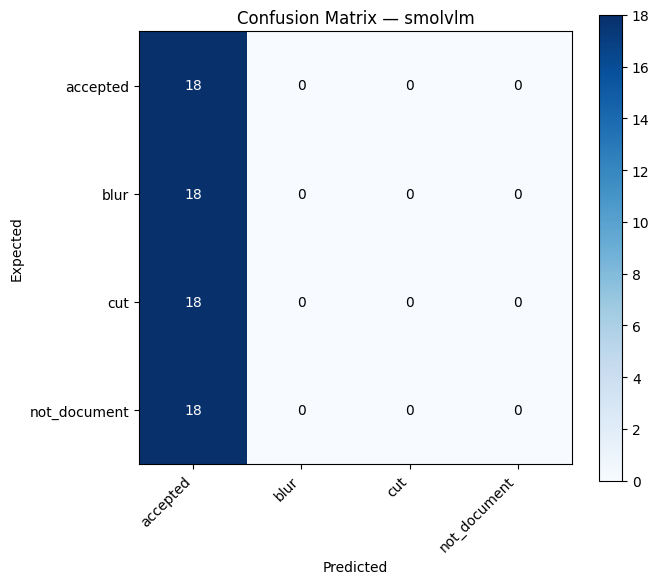

In [13]:
valid = results_df[results_df["predicted_label"] != "error"]
y_true, y_pred = valid["expected_label"], valid["predicted_label"]

print(f"Accuracy : {(y_true == y_pred).mean():.3f}")
print(classification_report(y_true, y_pred, labels=LABELS, zero_division=0))

cm = confusion_matrix(y_true, y_pred, labels=LABELS)
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(LABELS))); ax.set_xticklabels(LABELS, rotation=45, ha="right")
ax.set_yticks(range(len(LABELS))); ax.set_yticklabels(LABELS)
ax.set_xlabel("Predicted"); ax.set_ylabel("Expected")
ax.set_title(f"Confusion Matrix — {MODEL_KEY}")
for i in range(len(LABELS)):
    for j in range(len(LABELS)):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                color="white" if cm[i, j] > cm.max()/2 else "black")
plt.colorbar(im, ax=ax)
plt.tight_layout(); plt.show()

In [14]:
state_rows = []
for state, grp in valid.groupby("state"):
    yt, yp = grp["expected_label"], grp["predicted_label"]
    r = {"state": state, "n": len(grp), "accuracy": round((yt==yp).mean(), 3)}
    for cls in LABELS:
        if (yt==cls).any():
            r[f"{cls}_F1"] = round(f1_score(yt==cls, yp==cls, zero_division=0), 3)
    state_rows.append(r)
pd.DataFrame(state_rows).set_index("state").sort_values("accuracy", ascending=False)

,n,accuracy,accepted_F1,blur_F1,cut_F1,not_document_F1
state,,,,,,
TAMILNADU,4,0.500,0.667,0.0,NaN,0.0
Andhra_Pradesh,16,0.375,0.545,0.0,0.0,0.0
Karnataka,7,0.286,0.444,0.0,0.0,0.0
HARYANA,8,0.250,0.400,0.0,0.0,0.0
MADHYA_PRADESH,5,0.200,0.333,0.0,0.0,0.0
MAHARASHATRA,10,0.200,0.333,0.0,0.0,0.0
TELANGANA,5,0.200,0.333,0.0,0.0,0.0
PUNJAB,6,0.167,0.286,0.0,0.0,0.0
WEST_BENGAL,7,0.143,0.250,0.0,0.0,0.0


## 6. Model Comparison

In [ ]:
BENCHMARK_CSV = OUT_DIR / "vlm_benchmark.csv"
if not BENCHMARK_CSV.exists():
    print(f"Run vlm_benchmark.py first to populate {BENCHMARK_CSV}")
else:
    bench = pd.read_csv(BENCHMARK_CSV)
    summary_rows = []
    for model, grp in bench.groupby("model"):
        valid_g = grp[grp["predicted_label"] != "error"]
        yt, yp = valid_g["expected_label"], valid_g["predicted_label"]
        r = {
            "model": model, "n": len(valid_g),
            "accuracy": round((yt==yp).mean(), 3),
            "macro_f1": round(f1_score(yt, yp, labels=LABELS, average="macro", zero_division=0), 3),
            "median_latency_s": round(grp["latency_s"].median(), 2),
        }
        for cls in LABELS:
            r[f"{cls}_f1"] = round(f1_score(yt==cls, yp==cls, zero_division=0), 3)
        summary_rows.append(r)
    summary = pd.DataFrame(summary_rows).sort_values("macro_f1", ascending=False)
    display(summary.style.background_gradient(
        cmap="RdYlGn", subset=["macro_f1", "blur_f1", "accepted_f1"]
    ))